# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [102]:
# Your code here
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [103]:
# Your code here

# Assign value and unit for the speed
speed = 60 * u.kilometer / u.hour

# Convert units using .to() functon
conv_speed = speed.to(u.meter / u.second)

# Print the answer with the rounding
print(f"A {speed} in m / s is {conv_speed:.0f}.")

A 60.0 km / h in m / s is 17 m / s.


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [104]:
# Your comment here

# Julian Dates is a continuous count of days and fractions since noon Universal Time on January 1, 4713 BC (Wikipedia)

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [105]:
# Your comment here

# The biggest difference between the two systems is that 
# the average length of the Gregorian calendar year is 365.25 days 
# where that of the Julian calender year is 365.2425 days
# This was to follow the motion of the star more accurately

From the astropy module `time` import `Time` in the cell below.

In [106]:
# Your code here
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [107]:
# Your code here

# Use .now() function and .jd function(??) as in the lecture
current_jd_time = Time.now().jd  # Why does .jd not have (parenthesis) after if it is also a function(or method)???
print(f'The current time and date in Julian Date is: {current_jd_time}')

The current time and date in Julian Date is: 2460736.8053388144


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [108]:
# Your code here
# I will assume '20' instead of '02'
time_interested = Time('1969-07-20 20:17:00')

print(f'{time_interested} converted to Julian Date is: {time_interested.jd}.')

1969-07-20 20:17:00.000 converted to Julian Date is: 2440423.345138889.


What historically happened at this date and time?

In [109]:
# Your comment here 

# It is the date and time of the first lunar landing in UTC

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [110]:
# Your code here 

from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [111]:
# Define coordinates as taught in the lecture
ra = 15 * u.degree
dec = -20 * u.degree
frame = 'icrs'

coord_icrs = SkyCoord(ra=ra, dec=dec, frame=frame)

print(coord_icrs)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>


Convert the object's coordinates from ICRS to **Galactic**.

In [112]:
# Your code here

coord_in_gal = coord_icrs.transform_to(Galactic())

print(coord_in_gal)

<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [113]:
# Your code here

# Campbell Hall: 37.873199°N 122.257063°W
# From Wikipedia, the free encyclopedia
lat = 37.873199 * u.deg
lon = -122.257063 * u.deg
height = 25 * u.meter # Assume top of the building ~ 25m

# Define the position as instructed
us = EarthLocation(lat=lat, lon=lon, height=height)
right_now = Time.now()

altaz_frame = AltAz(obstime=right_now, location=us)
coord_altaz = coord_icrs.transform_to(altaz_frame)

print(coord_altaz)

<SkyCoord (AltAz: obstime=2025-03-02 07:19:42.276647, location=(-2690530.63037092, -4263068.39797982, 3894359.02783018) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (280.11687378, -45.40781564)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [114]:
# Your code here

# Import fits as instructed
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [115]:
# Your code here

from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [116]:
# Your code here

import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [117]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [118]:
# Your code here

# Follow the lecture instructions
with fits.open(image_file) as hdul:
    hdul.info() # Display whats going on in our file
    data = hdul[0].data # Get primary stuff
    header = hdul[0].header # Get header information

Filename: /Users/igeondong/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [119]:
# Your code here

# Call the array of data, find maximum
brightest = np.max(data)

print(f'Value of the brightest cell is: {brightest}')

Value of the brightest cell is: 22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [120]:
# Your code here

# Call the array of data, find minimum
dimmest = np.min(data)

print(f'Value of the least brightest cell is: {dimmest}')

Value of the least brightest cell is: 3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [121]:
# Your code here

# Import module as instructed
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [122]:
# Your code here

# Create table as instructed in the lecture
# Use data from Wikipedia
star_table = Table({'Name': ['Vega', 'Canopus', 'Antares'],
              'Magnitude': [0.03, -0.74, 0.96 ],
              'Spectral type': ['A0 Va', 'A9 II', 'M1.5 Iab-Ib, B2.5 V']})

Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [123]:
# Your code here

# Since .write is a method, maybe like this...?
star_table.write('star_table.fits', format='fits', overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [124]:
# Your code here

# Read the table as instructed
read_table = Table.read('star_table.fits', format='fits')

print(read_table)

  Name  Magnitude    Spectral type   
------- --------- -------------------
   Vega      0.03               A0 Va
Canopus     -0.74               A9 II
Antares      0.96 M1.5 Iab-Ib, B2.5 V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [125]:
# Your comment here

# A Hertzsprung-Russell (H-R) diagram is a useful scatter plot for main sequence stars
# It includes axes of absolute magnitude, luminosity, effective temperature, or size

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [126]:
# Your code here

import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [127]:
# Your code here

# Import the file by read_csv method and add the arguments
df = pd.read_csv('cluster_data.csv', skiprows=44, sep=';', header=None, index_col=0, 
                        names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'], skipfooter=1,
                        engine='python')

Display the first few rows of the data.

In [128]:
# Your code here

# Use data slicing, extract the first to 20th elements
print(df[0:20])

      Vmag      Plx     B-V       SpType
HIP                                     
10    8.59    10.76   0.489          F6V
11    7.34     4.29   0.081           A2
12    8.43     4.06   1.484        K4III
13    8.80     3.49   1.128        K0III
14    7.25     5.11   1.200           K0
15    8.60     2.45   1.166           K2
17    8.15     6.15   0.425          F3V
16   11.71     0.53   0.421          NaN
18   11.03    19.93   1.567           K5
19    6.53     4.12   0.955           G5
20    8.51    10.76   0.516           G0
21    7.55     5.84   1.438           K2
22    8.69     4.47   0.962  G8/K0III/IV
23    7.57    12.21   0.456          F2V
24    9.05     9.73   0.528          G0V
25    6.28    13.74   0.763         G3IV
26    9.13     9.19   0.535          F7V
27    9.32     9.66   0.671          G5V
28    8.83     5.64   0.468       F3/F5V
29    9.14     2.85   1.041        G8III


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [167]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

/var/folders/3x/qptr0_2135d837tjvpl_l_680000gn/T/ipykernel_29893/395354793.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [176]:
# Your code here

### I saved the 'no-NaN' version of dateframe with another name
### without this I encountered error on later sections
df_nonan = df_clean.dropna()
print(df_nonan)

         Vmag      Plx     B-V SpType
HIP                                  
10       8.59    10.76   0.489    F6V
11       7.34     4.29   0.081     A2
12       8.43     4.06   1.484  K4III
13       8.80     3.49   1.128  K0III
14       7.25     5.11   1.200     K0
...       ...      ...     ...    ...
118318   6.99     1.92   1.595     K2
118319   8.23    10.63   0.639    G2V
118320   7.59     5.00   0.999     K0
118321   9.20    19.22   0.698    G5V
118322   4.49     8.71  -0.075   B9IV

[114463 rows x 4 columns]


Run the cell below. We are converting the datatypes in the columns to floats.

In [177]:
df_nonan[['Vmag', 'Plx', 'B-V']] = df_nonan[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_nonan.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


/var/folders/3x/qptr0_2135d837tjvpl_l_680000gn/T/ipykernel_29893/3470614505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonan[['Vmag', 'Plx', 'B-V']] = df_nonan[['Vmag', 'Plx', 'B-V']].astype(float)


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [178]:
df_nonan['M_V'] = df_nonan['Vmag'] + 5 * np.log10(df_nonan['Plx'] / 100)
print(df_nonan[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/3x/qptr0_2135d837tjvpl_l_680000gn/T/ipykernel_29893/416604901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonan['M_V'] = df_nonan['Vmag'] + 5 * np.log10(df_nonan['Plx'] / 100)


Describe what the cell above is doing. 

In [179]:
# Your comment here

# The cell above creates a new table that contains the value of Plx and Vmag
# and their corresponding value of absolute magnitude

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [180]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_nonan['SpType2'] = df_nonan['SpType'].str[:2]

# Keep only valid spectral classes
df_nonan = df_nonan[df_nonan['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_nonan['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


/var/folders/3x/qptr0_2135d837tjvpl_l_680000gn/T/ipykernel_29893/4206432056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonan['SpType2'] = df_nonan['SpType'].str[:2]


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [181]:
# Your comment here

# Hottest: type 'O', about 28,000K ~ 50,000K
# Coldest: type 'M', about 2,500K ~ 3,500K

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [182]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_nonan['SpType2_numeric'] = df_nonan['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [183]:
# Your code here

import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

/var/folders/3x/qptr0_2135d837tjvpl_l_680000gn/T/ipykernel_29893/2470966598.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])  # After googling, I figured these features work


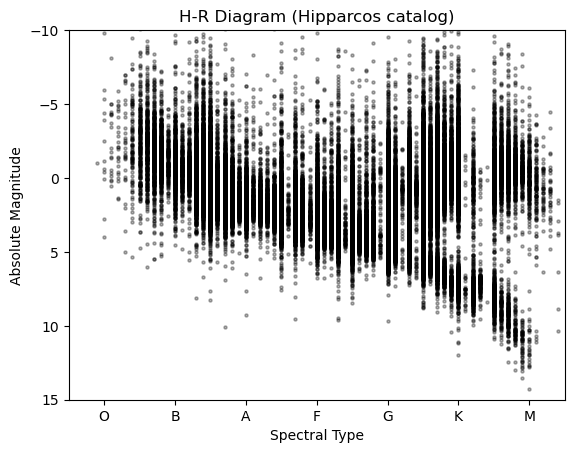

In [205]:
# Your code here

# Create a scatter plot and add required features
fig, ax = plt.subplots()
plt.scatter(df_nonan['SpType2_numeric'], df_nonan['M_V'], s=5, alpha=0.3, c='k')
plt.xlim((0, 70))
plt.ylim((15, -10))
ax.set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])  # After googling, I figured these features work
ax.set_xticks(range(5,75,10))                            # only on subplot environments (fig, ax)
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')

plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

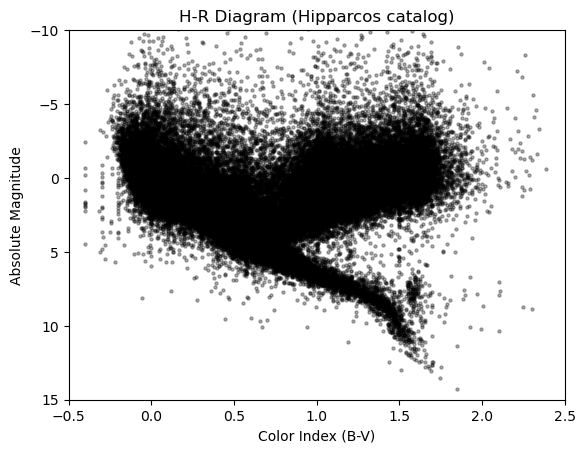

In [207]:
# Your code here

# Create a scatter plot and add required features
fig, ax = plt.subplots()
plt.scatter(df_nonan['B-V'], df_nonan['M_V'], s=5, alpha=0.3, c='k')
plt.xlim((-0.5, 2.5))
plt.ylim((15, -10))
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')

plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

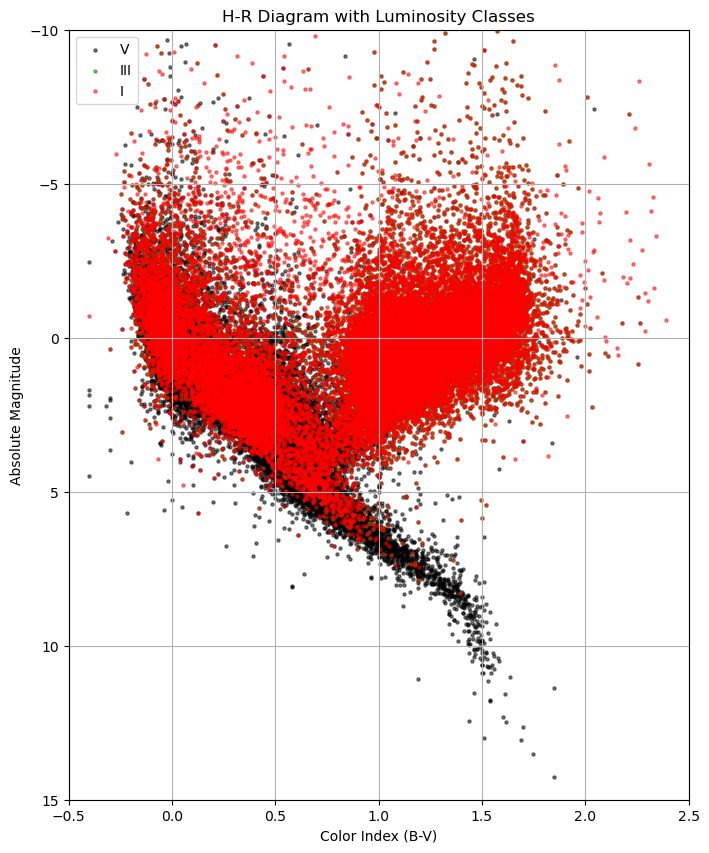

In [214]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_nonan, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_nonan, 'III', 'green')  # Giants
plot_luminosity_class(df_nonan, 'I', 'red')  # Supergiants

plt.legend()
plt.show()

With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

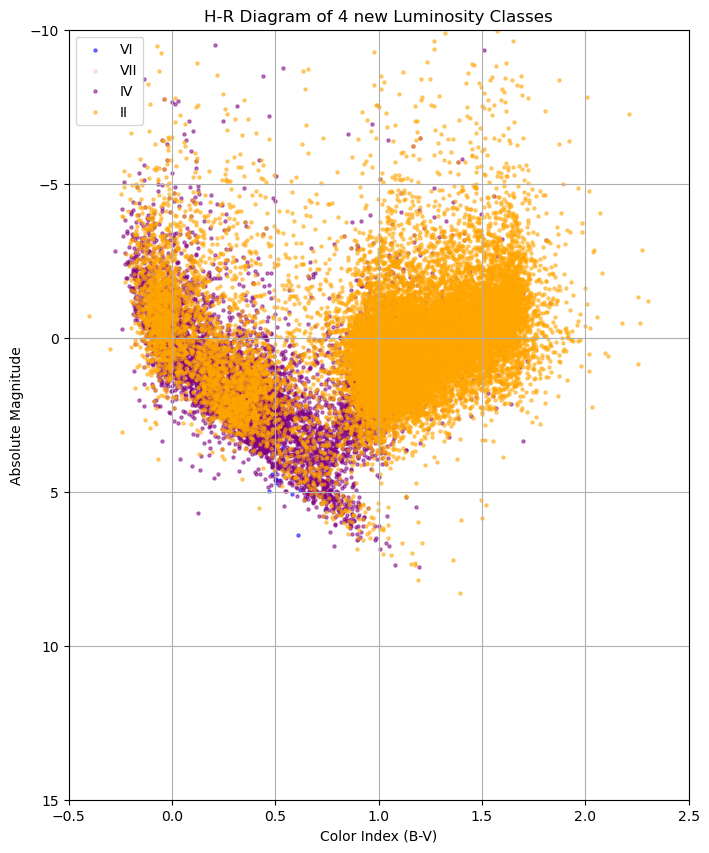

In [218]:
# Your code here

# Use the provided code!
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram of 4 new Luminosity Classes')

plot_luminosity_class(df_nonan, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_nonan, 'VII', 'pink')  # White dwarfs
plot_luminosity_class(df_nonan, 'IV', 'purple')  # Subgiants
plot_luminosity_class(df_nonan, 'II', 'orange')  # Bright giants

plt.legend()
plt.show()

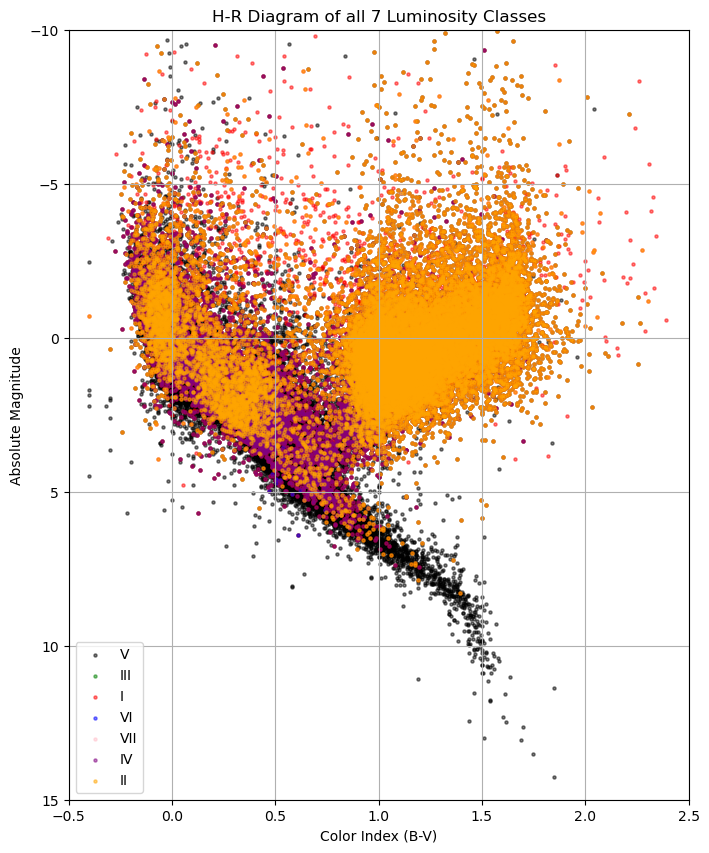

In [219]:
# Combine all types
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram of all 7 Luminosity Classes')

plot_luminosity_class(df_nonan, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_nonan, 'III', 'green')  # Giants
plot_luminosity_class(df_nonan, 'I', 'red')  # Supergiants
plot_luminosity_class(df_nonan, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_nonan, 'VII', 'pink')  # White dwarfs
plot_luminosity_class(df_nonan, 'IV', 'purple')  # Subgiants
plot_luminosity_class(df_nonan, 'II', 'orange')  # Bright giants

plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!